Simulating camera sensor...
Raw Bayer grid saved successfully to: /home/xilinx/pynq/overlays/NiraGarage/ISP/simulated_bayer_grid.png


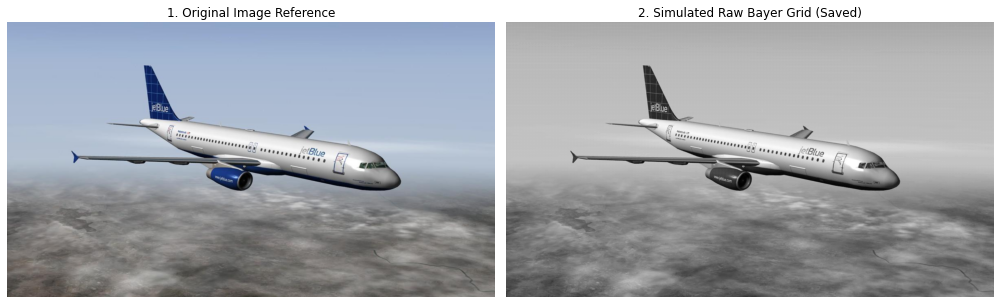

In [5]:
'''
RAW BAYER IMAGE GENERATION USING PYTHON
'''
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_bayer_input(image_path, width=1280, height=720):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image from {image_path}")
    
    img_resized = cv2.resize(img, (width, height))
    bayer = np.zeros((height, width), dtype=np.uint8)
    
    # Simulate standard RGGB Bayer pattern
    bayer[0::2, 0::2] = img_resized[0::2, 0::2, 2] # Red
    bayer[0::2, 1::2] = img_resized[0::2, 1::2, 1] # Green
    bayer[1::2, 0::2] = img_resized[1::2, 0::2, 1] # Green
    bayer[1::2, 1::2] = img_resized[1::2, 1::2, 0] # Blue
    
    return img_resized, bayer

# Paths
image_path = "/home/xilinx/pynq/overlays/NiraGarage/ISP/test_image_7.jpg"
saved_bayer_path = "/home/xilinx/pynq/overlays/NiraGarage/ISP/simulated_bayer_grid.png"

print("Simulating camera sensor...")
original_color, bayer_data = create_bayer_input(image_path)

# Save the raw Bayer grid to disk
cv2.imwrite(saved_bayer_path, bayer_data)
print(f"Raw Bayer grid saved successfully to: {saved_bayer_path}")

# Display the Original vs the Bayer Grid
original_rgb = cv2.cvtColor(original_color, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(original_rgb)
axes[0].set_title("1. Original Image Reference", fontsize=12)
axes[0].axis('off')

# Displaying in grayscale to strictly show the raw intensity values
axes[1].imshow(bayer_data, cmap='gray')
axes[1].set_title("2. Simulated Raw Bayer Grid (Saved)", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

Loading overlay...
Allocating physical DMA buffers...
Starting FPGA Processing...
FPGA Processing Complete in 0.0120 seconds!


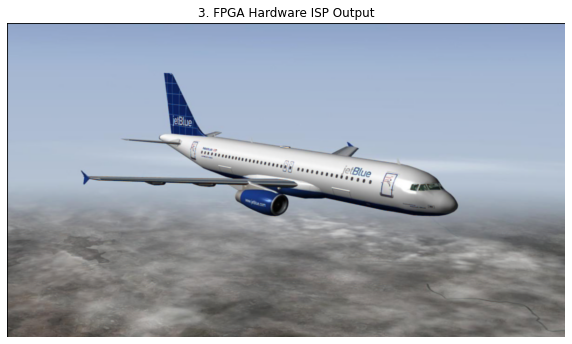

In [6]:
'''
FPGA INFERENCE FOR IMAGE SIGNAL PROCESSOR CORE
'''
from pynq import Overlay, allocate
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

# 1. Setup & Load Hardware
print("Loading overlay...")
overlay = Overlay("/home/xilinx/pynq/overlays/NiraGarage/ISP/design_1_wrapper.bit")

dma = overlay.axi_dma_0
isp_ip = overlay.isp_hls_top_0

dma.recvchannel._max_size = 8388607
dma.sendchannel._max_size = 8388607

# 2. Load the SAVED Bayer Grid
saved_bayer_path = "/home/xilinx/pynq/overlays/NiraGarage/ISP/simulated_bayer_grid.png"
bayer_data = cv2.imread(saved_bayer_path, cv2.IMREAD_GRAYSCALE)

if bayer_data is None:
    raise FileNotFoundError("Could not find the saved Bayer image. Run Cell 1 first!")

# 3. Memory Allocation
print("Allocating physical DMA buffers...")
in_buffer = allocate(shape=(720, 1280), dtype=np.uint32)
out_buffer = allocate(shape=(720, 1280), dtype=np.uint32)

in_buffer[:] = 0
out_buffer[:] = 0

# Pack loaded 8-bit Bayer data into the 32-bit DMA buffer
in_buffer[:] = bayer_data.astype(np.uint32)

# 4. Hardware Execution
print("Starting FPGA Processing...")

try:
    isp_ip.write(0x10, 16) # Gain = 1.0
except:
    print("Warning: Could not write to gain register.")

isp_ip.write(0x00, 0x1) # AP_START

start_time = time.time()

dma.recvchannel.transfer(out_buffer)
dma.sendchannel.transfer(in_buffer)

dma.sendchannel.wait()
dma.recvchannel.wait()

end_time = time.time()
print(f"FPGA Processing Complete in {end_time - start_time:.4f} seconds!")

# 5. Reconstruct and Display Output
raw_output = out_buffer.view(np.uint8).reshape(720, 1280, 4)

final_image = np.zeros((720, 1280, 3), dtype=np.uint8)
final_image[:, :, 0] = raw_output[:, :, 0] 
final_image[:, :, 1] = raw_output[:, :, 1] 
final_image[:, :, 2] = raw_output[:, :, 2] 

output_path = "/home/xilinx/pynq/overlays/NiraGarage/ISP/pynq_hardware_output.png"
cv2.imwrite(output_path, final_image)

# Final display
display_rgb=final_image
plt.figure(figsize=(10, 6))
plt.imshow(display_rgb)
plt.title("3. FPGA Hardware ISP Output", fontsize=12)
plt.axis('off')
plt.show()

# Free allocated physical memory
in_buffer.close()
out_buffer.close()

Starting CPU Processing...
CPU Processing Complete in 0.1589 seconds!
Saved CPU processed image as '/home/xilinx/pynq/overlays/NiraGarage/ISP/pynq_cpu_output.png'


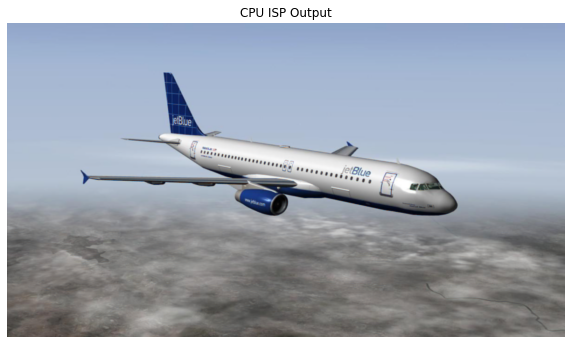

In [7]:
'''
CPU INFERENCE FOR IMAGE SIGNAL PROCESSOR CORE
'''
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt

# ==========================================
# 1. Load the SAVED Bayer Grid
# ==========================================
saved_bayer_path = "/home/xilinx/pynq/overlays/NiraGarage/ISP/simulated_bayer_grid.png"
bayer_data = cv2.imread(saved_bayer_path, cv2.IMREAD_GRAYSCALE)

if bayer_data is None:
    raise FileNotFoundError("Could not find the saved Bayer image. Run Cell 1 first!")

print("Starting CPU Processing...")
start_time = time.time()

# ==========================================
# 2. CPU Demosaicing (Color Reconstruction)
# ==========================================
# OpenCV has built-in high-speed demosaicing. 
# Since we simulated an RGGB pattern, we use COLOR_BayerBG2BGR or COLOR_BayerRG2BGR.
# (OpenCV names it based on the 2nd row's first elements sometimes, let's use BayerBG2BGR).
cpu_processed_bgr = cv2.cvtColor(bayer_data, cv2.COLOR_BayerBG2BGR)

# ==========================================
# 3. CPU Gain Control
# ==========================================
# Your FPGA had a gain setting. To mimic that on the CPU, we multiply the image.
gain = 1.0 
cpu_processed_bgr = cv2.convertScaleAbs(cpu_processed_bgr, alpha=gain, beta=0)

end_time = time.time()
print(f"CPU Processing Complete in {end_time - start_time:.4f} seconds!")

# ==========================================
# 4. Save and Display the Output
# ==========================================
output_path = "/home/xilinx/pynq/overlays/NiraGarage/ISP/pynq_cpu_output.png"
cv2.imwrite(output_path, cpu_processed_bgr)
print(f"Saved CPU processed image as '{output_path}'")

# Convert OpenCV BGR to RGB for correct rendering in Matplotlib
display_rgb = cv2.cvtColor(cpu_processed_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(display_rgb)
plt.title("CPU ISP Output", fontsize=12)
plt.axis('off')
plt.show()

Loading overlay...
Starting CPU Processing...
CPU Complete in 0.1586 seconds (6.31 FPS)
Starting FPGA Processing...
FPGA Complete in 0.0121 seconds (82.40 FPS)


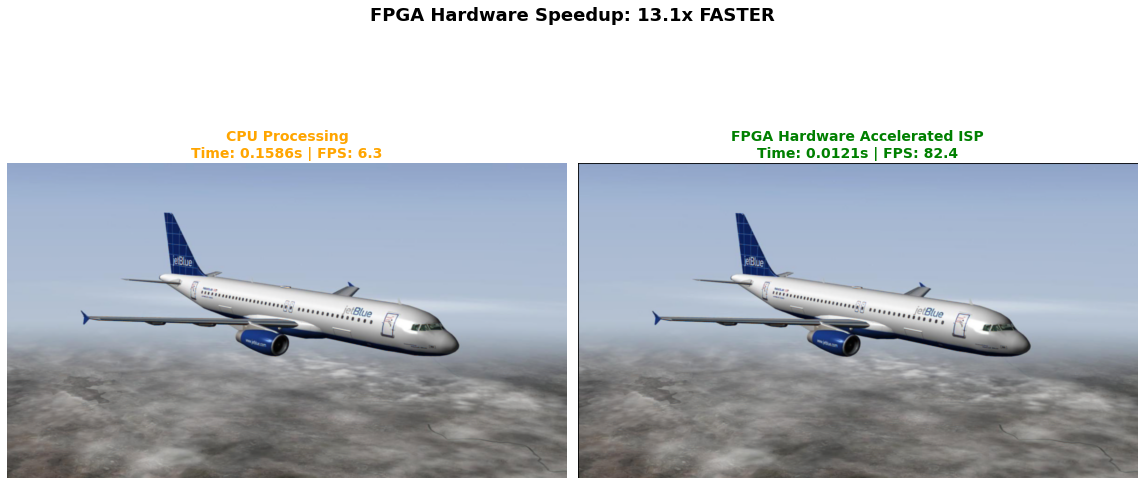

In [8]:
'''
COMPARISION BETWEEN CPU AND FPGA
'''
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from pynq import Overlay, allocate

# ==========================================
# 1. Setup / Hardware Initialization
# ==========================================
print("Loading overlay...")
overlay = Overlay("/home/xilinx/pynq/overlays/NiraGarage/ISP/design_1_wrapper.bit")

dma = overlay.axi_dma_0
isp_ip = overlay.isp_hls_top_0

dma.recvchannel._max_size = 8388607
dma.sendchannel._max_size = 8388607

# ==========================================
# 2. Load Shared Input Data
# ==========================================
saved_bayer_path = "/home/xilinx/pynq/overlays/NiraGarage/ISP/simulated_bayer_grid.png"
bayer_data = cv2.imread(saved_bayer_path, cv2.IMREAD_GRAYSCALE)

if bayer_data is None:
    raise FileNotFoundError("Could not find the saved Bayer image. Run your Bayer generation cell first!")

# ==========================================
# 3. Method A: CPU Inference Execution
# ==========================================
print("Starting CPU Processing...")
cpu_start = time.time()

# Demosaic and apply gain
cpu_bgr = cv2.cvtColor(bayer_data, cv2.COLOR_BayerBG2BGR)
cpu_bgr = cv2.convertScaleAbs(cpu_bgr, alpha=1.0, beta=0)

cpu_time = time.time() - cpu_start
cpu_fps = 1.0 / cpu_time
print(f"CPU Complete in {cpu_time:.4f} seconds ({cpu_fps:.2f} FPS)")

# ==========================================
# 4. Method B: FPGA Inference Execution
# ==========================================
print("Starting FPGA Processing...")

in_buffer = allocate(shape=(720, 1280), dtype=np.uint32)
out_buffer = allocate(shape=(720, 1280), dtype=np.uint32)
in_buffer[:] = bayer_data.astype(np.uint32)
out_buffer[:] = 0

try:
    isp_ip.write(0x10, 16) # Gain = 1.0
except:
    pass
isp_ip.write(0x00, 0x1) # AP_START

fpga_start = time.time()

dma.recvchannel.transfer(out_buffer)
dma.sendchannel.transfer(in_buffer)
dma.sendchannel.wait()
dma.recvchannel.wait()

fpga_time = time.time() - fpga_start
fpga_fps = 1.0 / fpga_time
print(f"FPGA Complete in {fpga_time:.4f} seconds ({fpga_fps:.2f} FPS)")

# Reconstruct image from hardware packed bytes (fixing the channel swap)
raw_output = out_buffer.view(np.uint8).reshape(720, 1280, 4)
fpga_bgr = np.zeros((720, 1280, 3), dtype=np.uint8)
fpga_bgr[:, :, 0] = raw_output[:, :, 2] # Blue
fpga_bgr[:, :, 1] = raw_output[:, :, 1] # Green
fpga_bgr[:, :, 2] = raw_output[:, :, 0] # Red

# ==========================================
# 5. Generate Visual Comparison
# ==========================================
# Convert both to RGB for correct plotting in Matplotlib
cpu_rgb = cv2.cvtColor(cpu_bgr, cv2.COLOR_BGR2RGB)
fpga_rgb = cv2.cvtColor(fpga_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Subplot 1: CPU
axes[0].imshow(cpu_rgb)
axes[0].set_title(f"CPU Processing\nTime: {cpu_time:.4f}s | FPS: {cpu_fps:.1f}", 
                  fontsize=14, color='orange', fontweight='bold')
axes[0].axis('off')

# Subplot 2: FPGA
axes[1].imshow(fpga_rgb)
axes[1].set_title(f"FPGA Hardware Accelerated ISP\nTime: {fpga_time:.4f}s | FPS: {fpga_fps:.1f}", 
                  fontsize=14, color='green', fontweight='bold')
axes[1].axis('off')

# Calculate speedup percentage
speedup = cpu_time / fpga_time
plt.suptitle(f"FPGA Hardware Speedup: {speedup:.1f}x FASTER", 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Free allocated physical memory
in_buffer.close()
out_buffer.close()